# Final Results Overview

Display-only notebook for the saved project figures and CSV results, organized by Part 1, Part 2, and Part 3.

In [14]:
from pathlib import Path
import re
import sys
from typing import Optional

import pandas as pd
from IPython.display import Image as DisplayImage
from IPython.display import Markdown, display


def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing src/ and outputs/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
INTERMEDIATE_FIGURES_DIR = FIGURES_DIR / "intermediate"

PROJECT_ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [15]:
TIMESTAMP_SUFFIX = re.compile(r"_(\d{8}_\d{6})$")


def relative_path(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def intermediate_family(path: Path) -> str:
    return TIMESTAMP_SUFFIX.sub("", path.stem)


def latest_intermediate_figures(prefix: Optional[str] = None) -> list[Path]:
    figures = sorted(INTERMEDIATE_FIGURES_DIR.glob("*.png"))
    if prefix is not None:
        figures = [path for path in figures if path.name.startswith(prefix)]

    latest_by_family: dict[str, Path] = {}
    for path in figures:
        family = intermediate_family(path)
        current = latest_by_family.get(family)
        if current is None:
            latest_by_family[family] = path
            continue

        current_is_canonical = current.stem == family
        path_is_canonical = path.stem == family
        if path_is_canonical and not current_is_canonical:
            latest_by_family[family] = path
        elif path_is_canonical == current_is_canonical and path.stat().st_mtime > current.stat().st_mtime:
            latest_by_family[family] = path

    return [latest_by_family[key] for key in sorted(latest_by_family)]


def show_image(path: Path) -> None:
    if not path.exists():
        display(Markdown(f"**Missing:** `{relative_path(path)}`"))
        return
    display(Markdown(f"**{relative_path(path)}**"))
    display(DisplayImage(filename=str(path)))


def show_images(paths: list[Path]) -> None:
    if not paths:
        display(Markdown("No figures found."))
        return
    for path in paths:
        show_image(path)


def show_table(path: Path, rows: int = 20) -> None:
    if not path.exists():
        display(Markdown(f"**Missing:** `{relative_path(path)}`"))
        return
    frame = pd.read_csv(path)
    display(Markdown(f"**{relative_path(path)}** - {len(frame)} rows x {len(frame.columns)} columns"))
    display(frame.head(rows))


def show_tables(paths: list[Path], rows: int = 20) -> None:
    for path in paths:
        show_table(path, rows=rows)

## Part 1

### Latest Intermediate Graphs

**outputs/figures/intermediate/part1_accuracy_vs_tiles_deit_tiny.png**

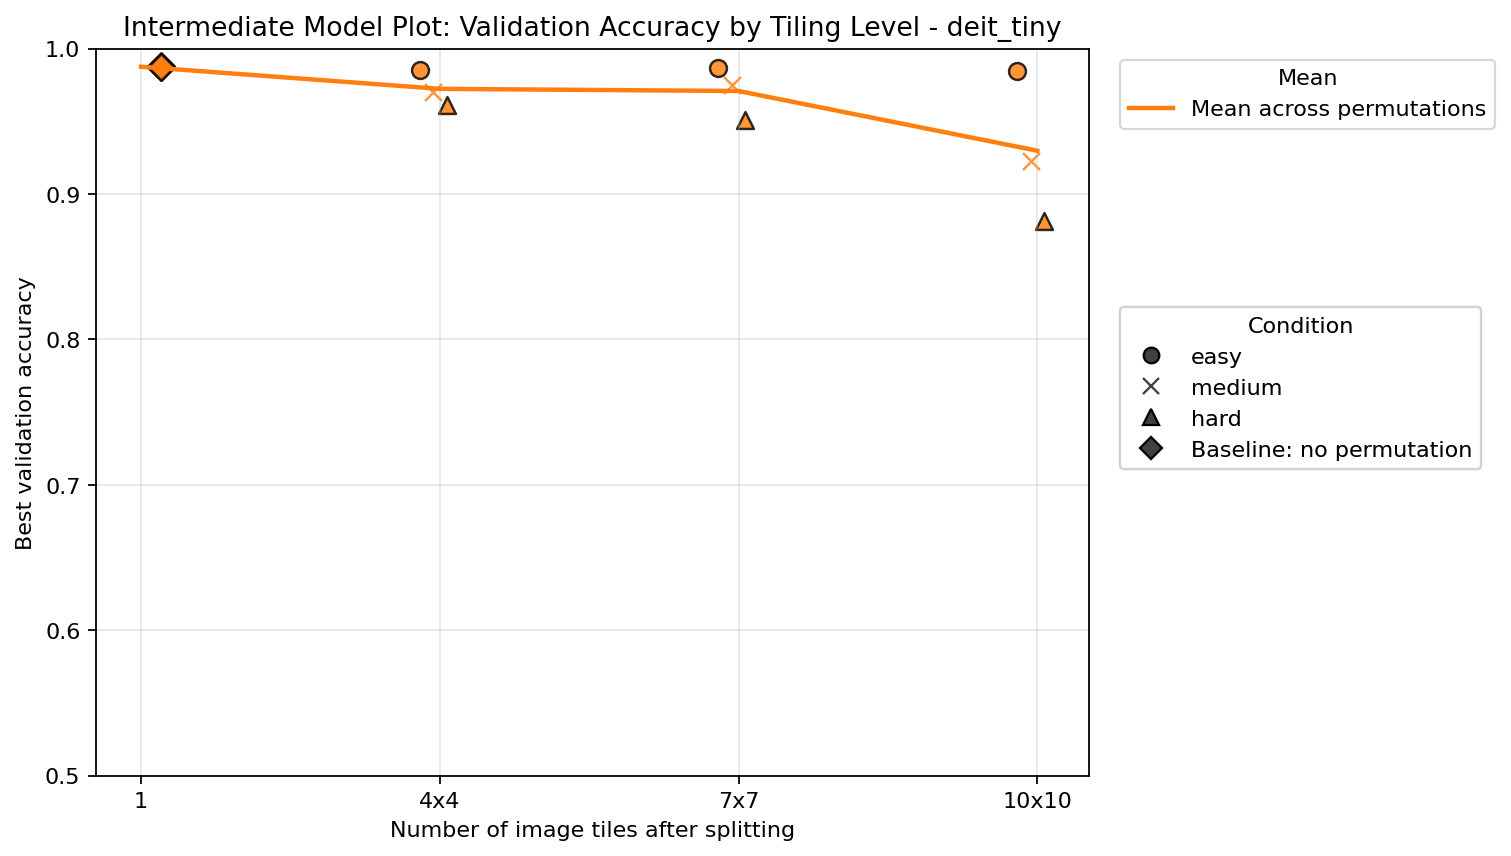

**outputs/figures/intermediate/part1_accuracy_vs_tiles_mlp_mixer_base.png**

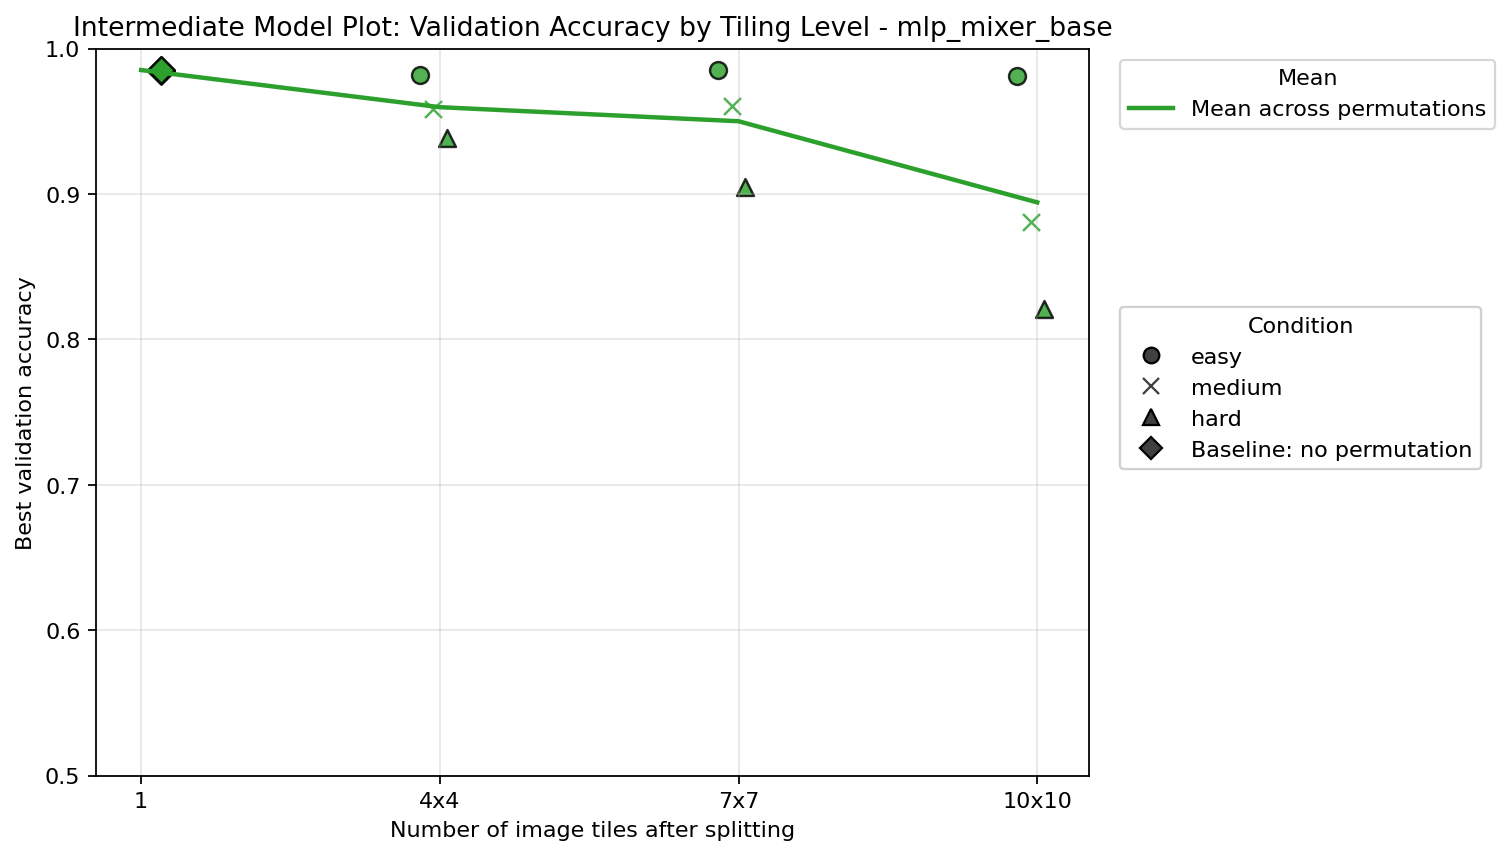

**outputs/figures/intermediate/part1_accuracy_vs_tiles_resnet18.png**

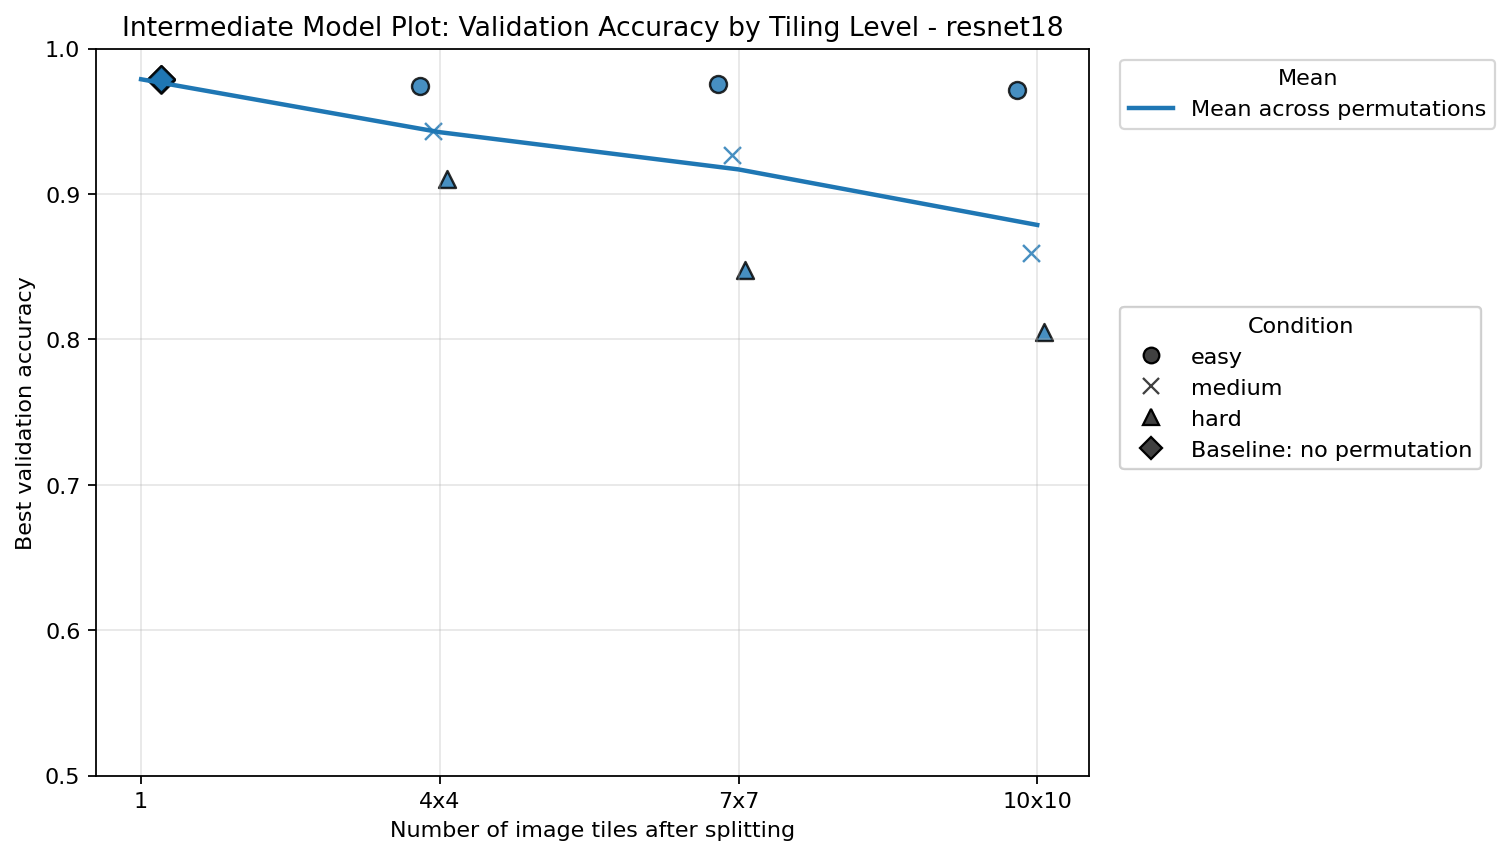

In [16]:
show_images(latest_intermediate_figures("part1_"))

In [17]:
# show_tables(
#     [
#         RESULTS_DIR / "part1_raw_results.csv",
#         RESULTS_DIR / "part1_aggregated_results.csv",
#         RESULTS_DIR / "part1_tile_permutations.csv",
#     ]
# )

### Final graph

**outputs/figures/part1_accuracy_vs_tiles.png**

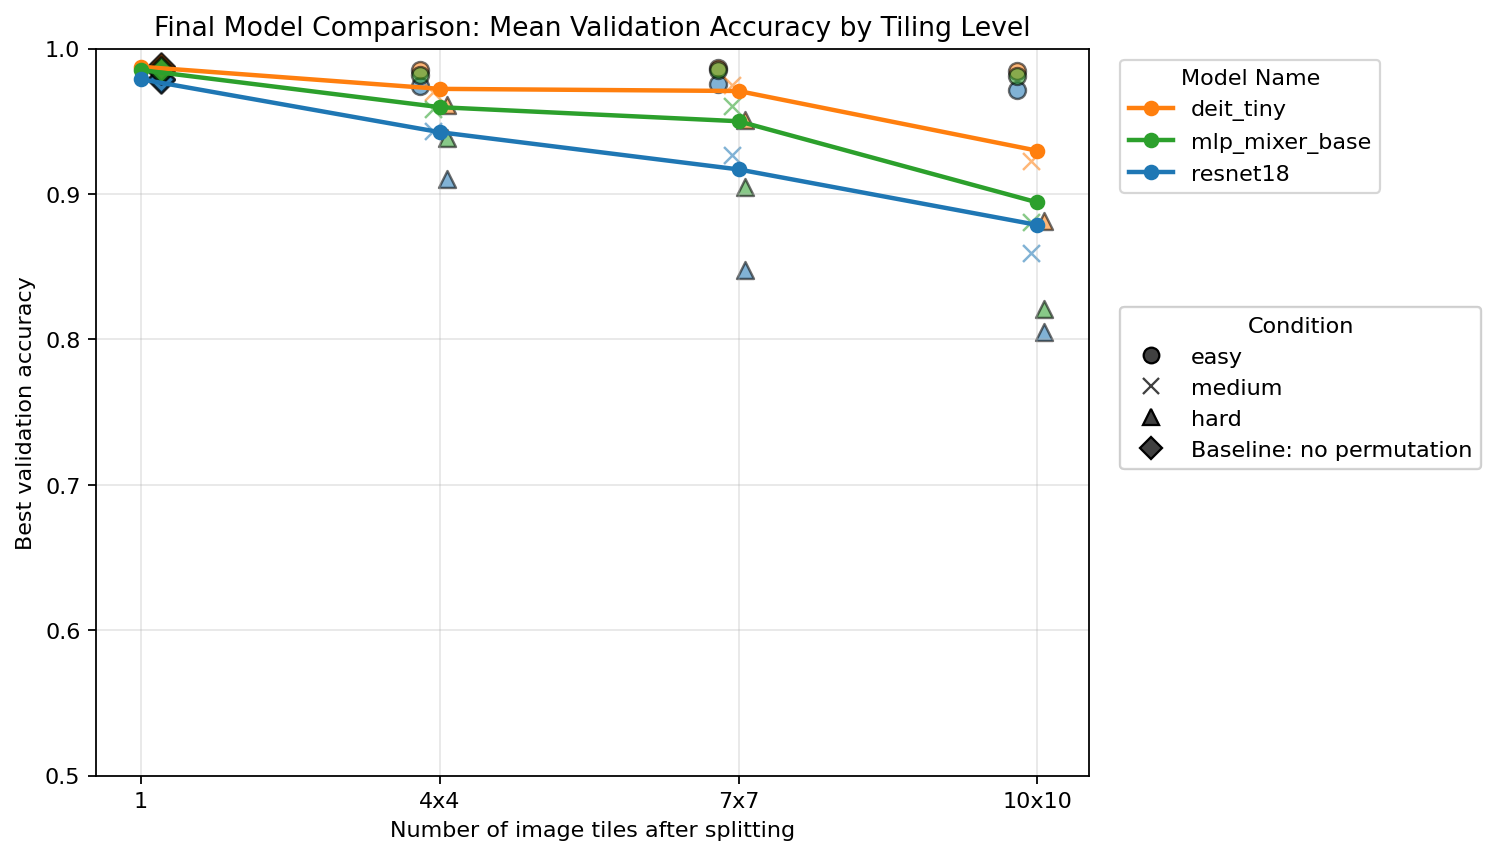

In [18]:
show_image(FIGURES_DIR / "part1_accuracy_vs_tiles.png")

## Part 2

In [19]:
from src.evaluation.experiment_results import refresh_part2_ablation_comparison_figure

refresh_paths = refresh_part2_ablation_comparison_figure(
    results_dir=str(RESULTS_DIR),
    figures_dir=str(FIGURES_DIR),
)
pd.DataFrame([refresh_paths])

,figure,original_figure,aggregated_results,raw_results
0,/Users/royrubin/Documents/GitHub/MLDS_Final_Pr...,/Users/royrubin/Documents/GitHub/MLDS_Final_Pr...,/Users/royrubin/Documents/GitHub/MLDS_Final_Pr...,/Users/royrubin/Documents/GitHub/MLDS_Final_Pr...


### Latest Intermediate Graphs

**outputs/figures/intermediate/part2_ablation_augmentation_patch_shuffle.png**

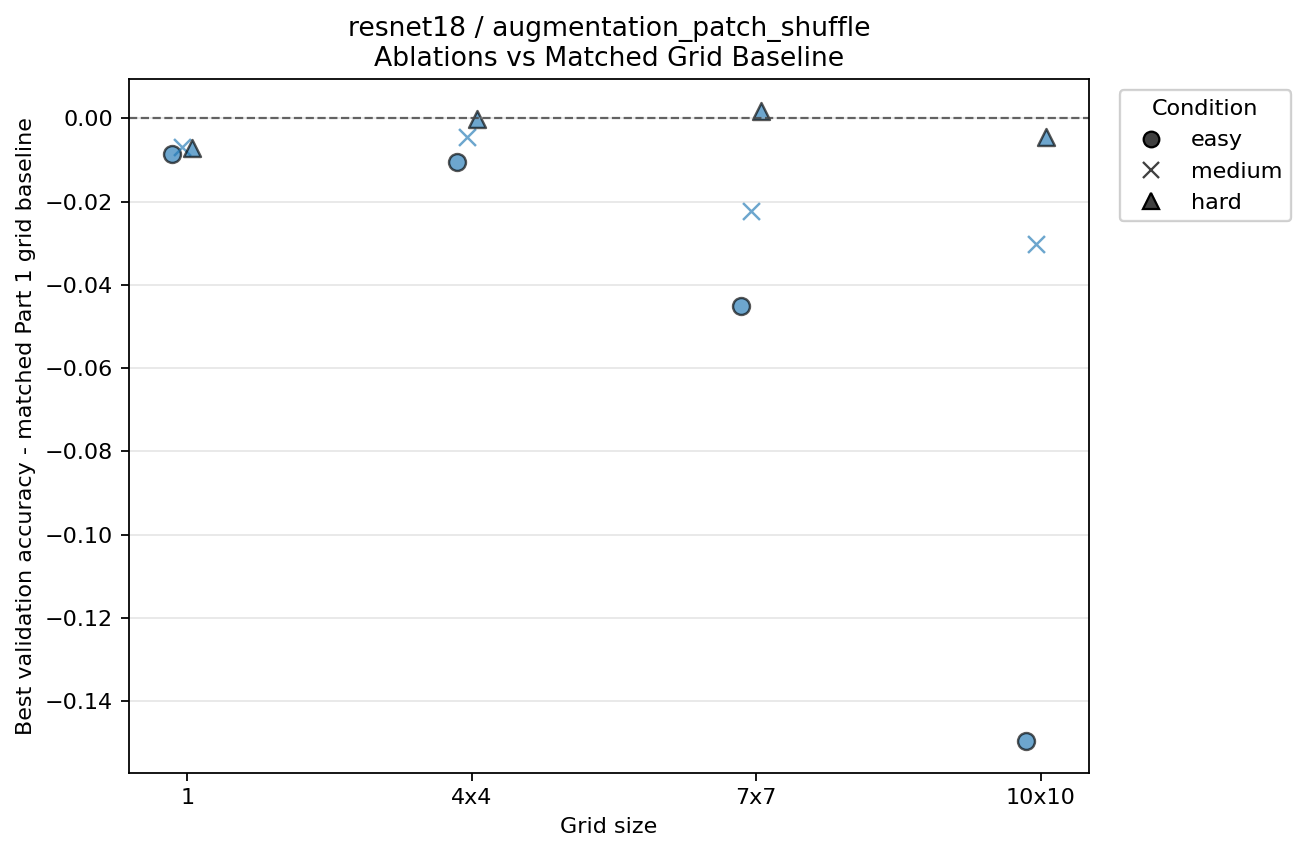

**outputs/figures/intermediate/part2_ablation_curriculum_corruption_probability.png**

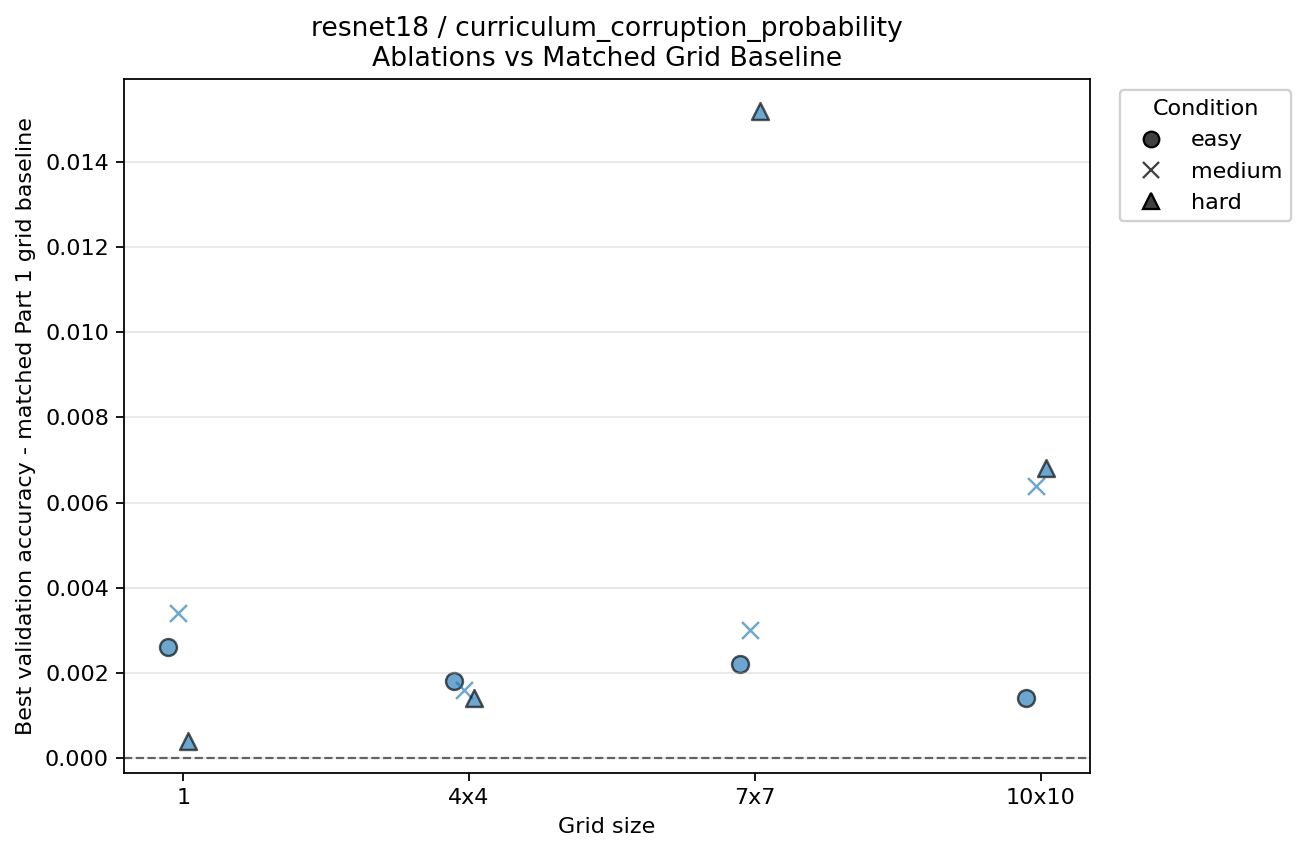

**outputs/figures/intermediate/part2_ablation_curriculum_permutation_difficulty.png**

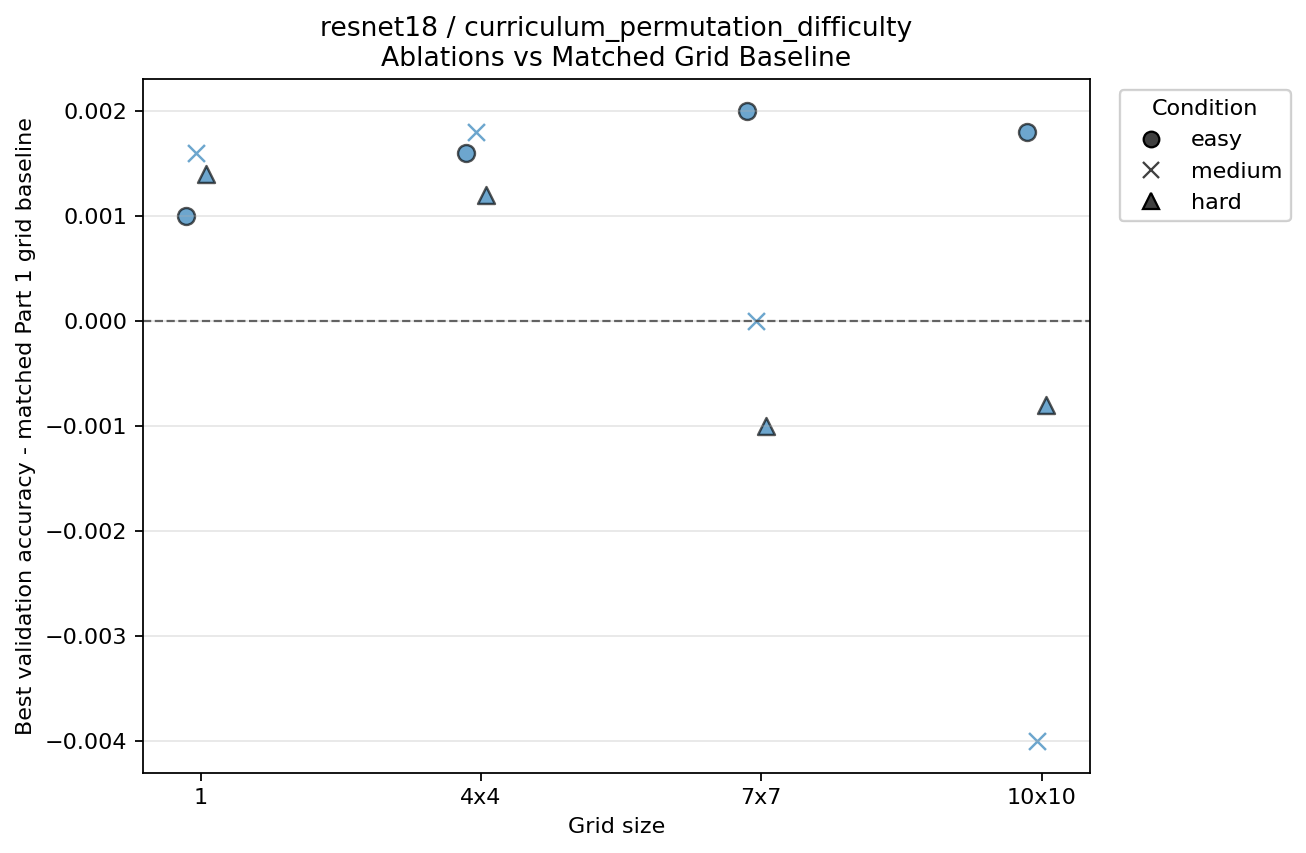

**outputs/figures/intermediate/part2_ablation_mixed_original_permuted.png**

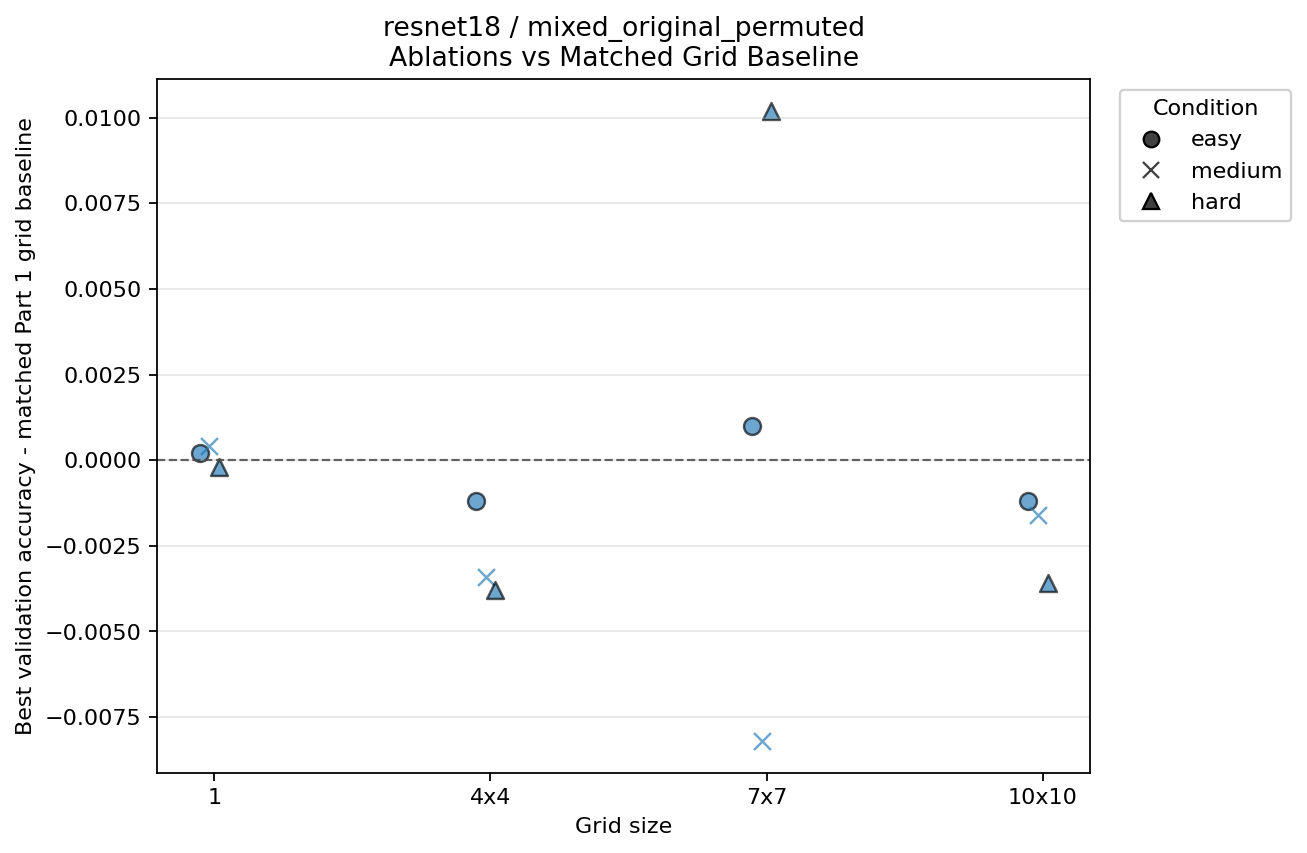

**outputs/figures/intermediate/part2_ablation_regular_augmentations.png**

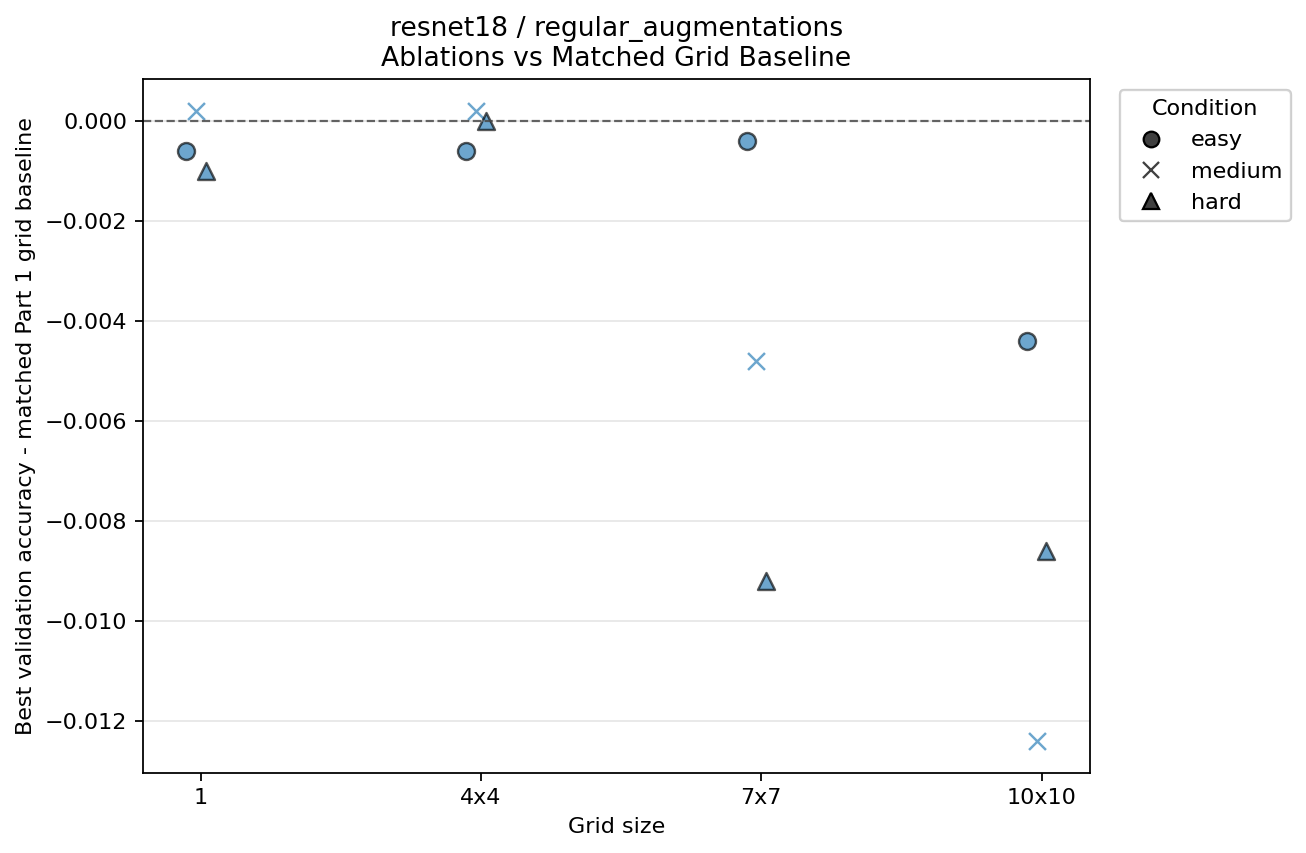

**outputs/figures/intermediate/part2_ablation_resnet18_mlp_head.png**

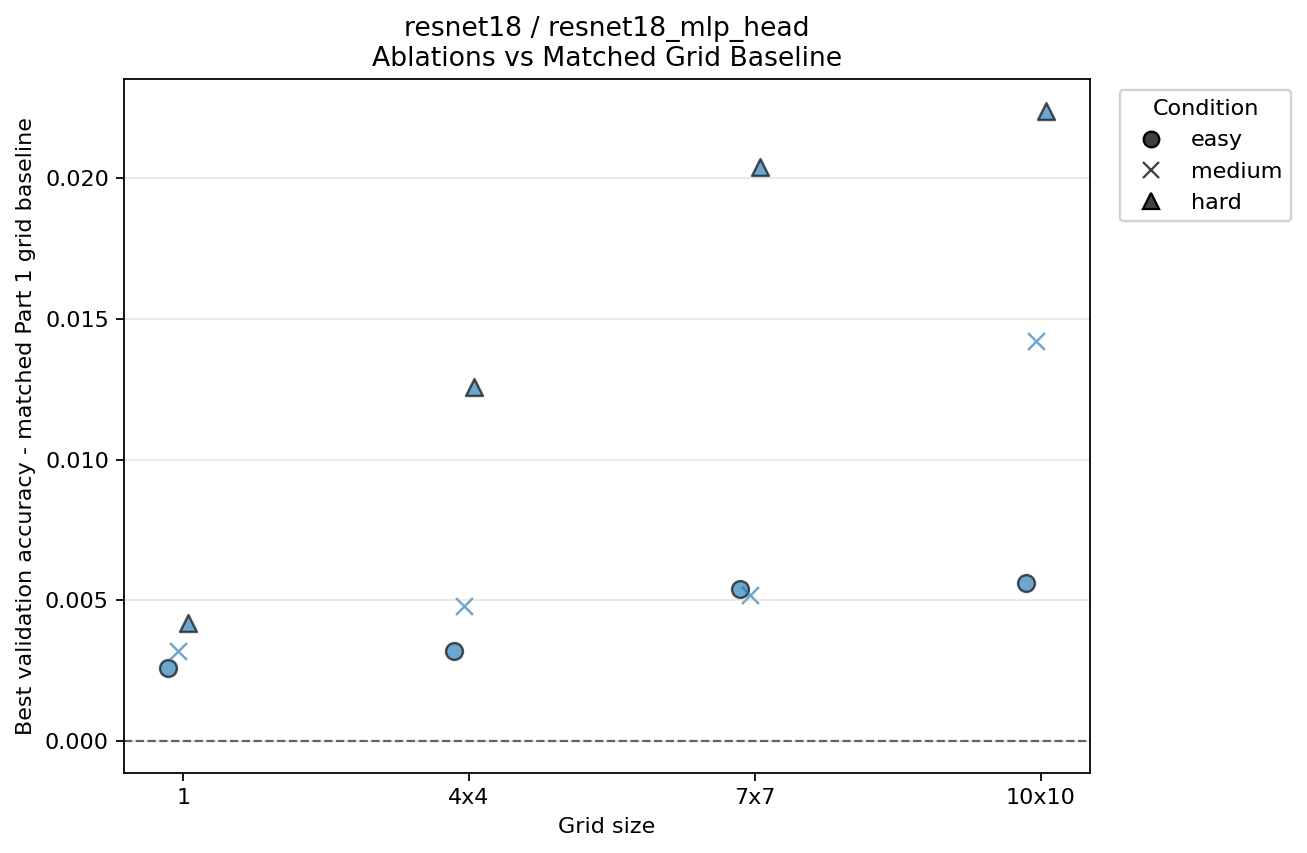

In [20]:
show_images(latest_intermediate_figures("part2_"))

In [21]:
# show_tables(
#     [
#         RESULTS_DIR / "part2_raw_results.csv",
#         RESULTS_DIR / "part2_aggregated_results.csv",
#     ]
# )

### Final graph

**outputs/figures/part2_ablation_comparison.png**

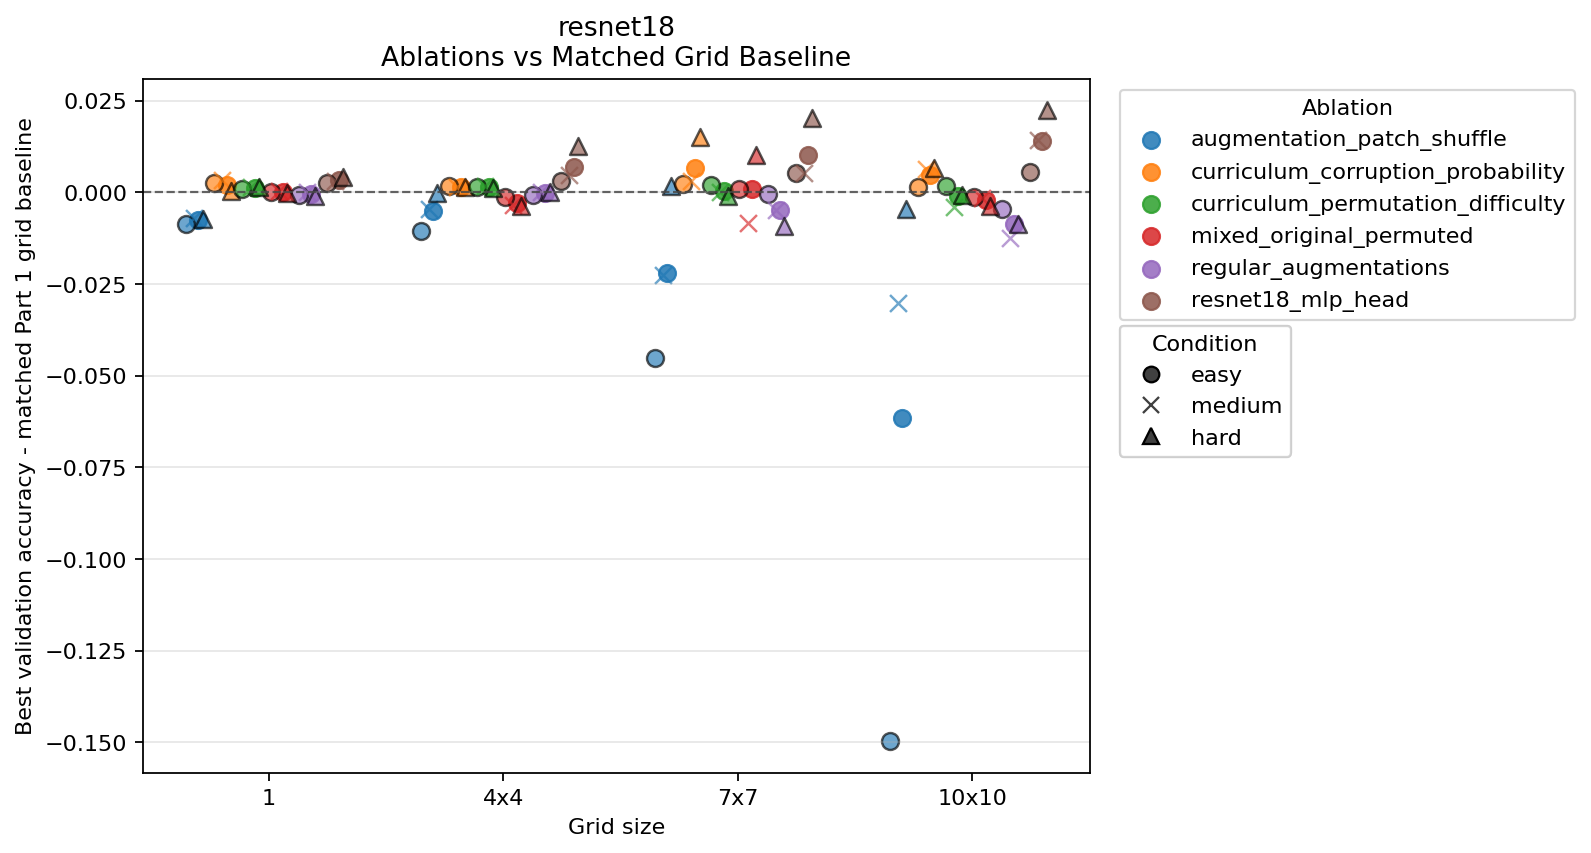

In [22]:
show_image(FIGURES_DIR / "part2_ablation_comparison.png")

## Part 3

**outputs/figures/part3_adjacency_destruction_hardness_grid_vs_hardness.png**

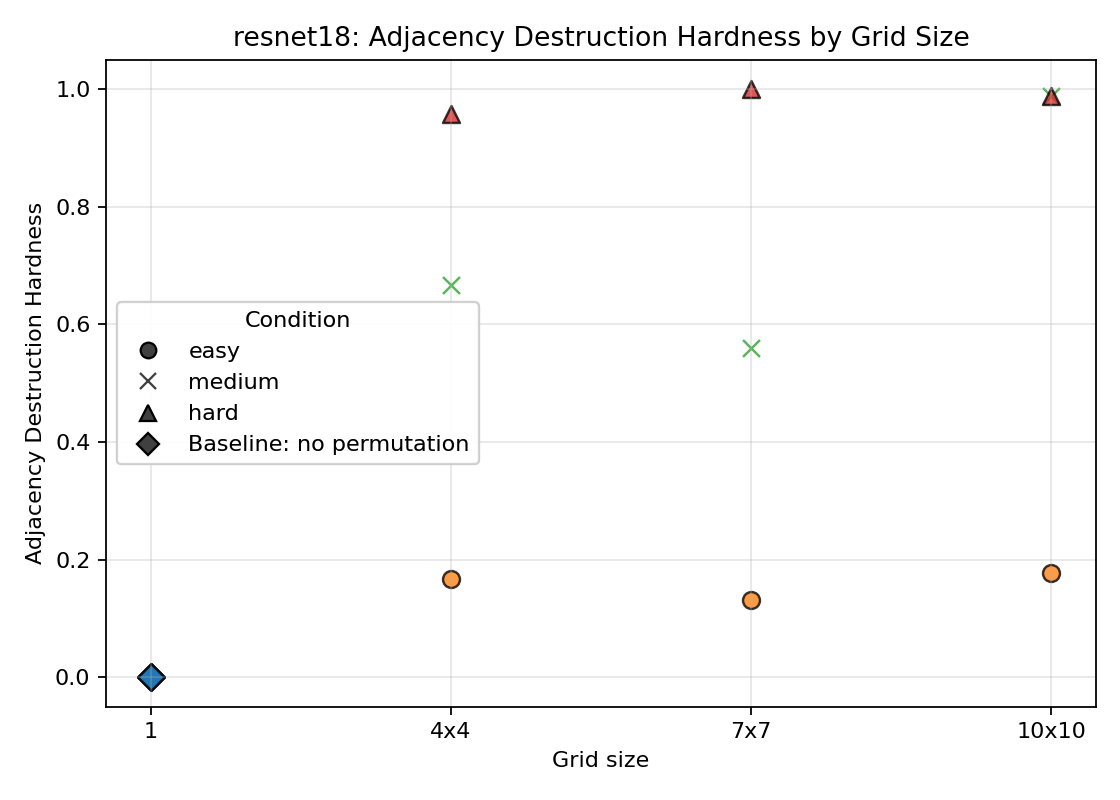

**outputs/figures/part3_combined_hardness_grid_vs_hardness.png**

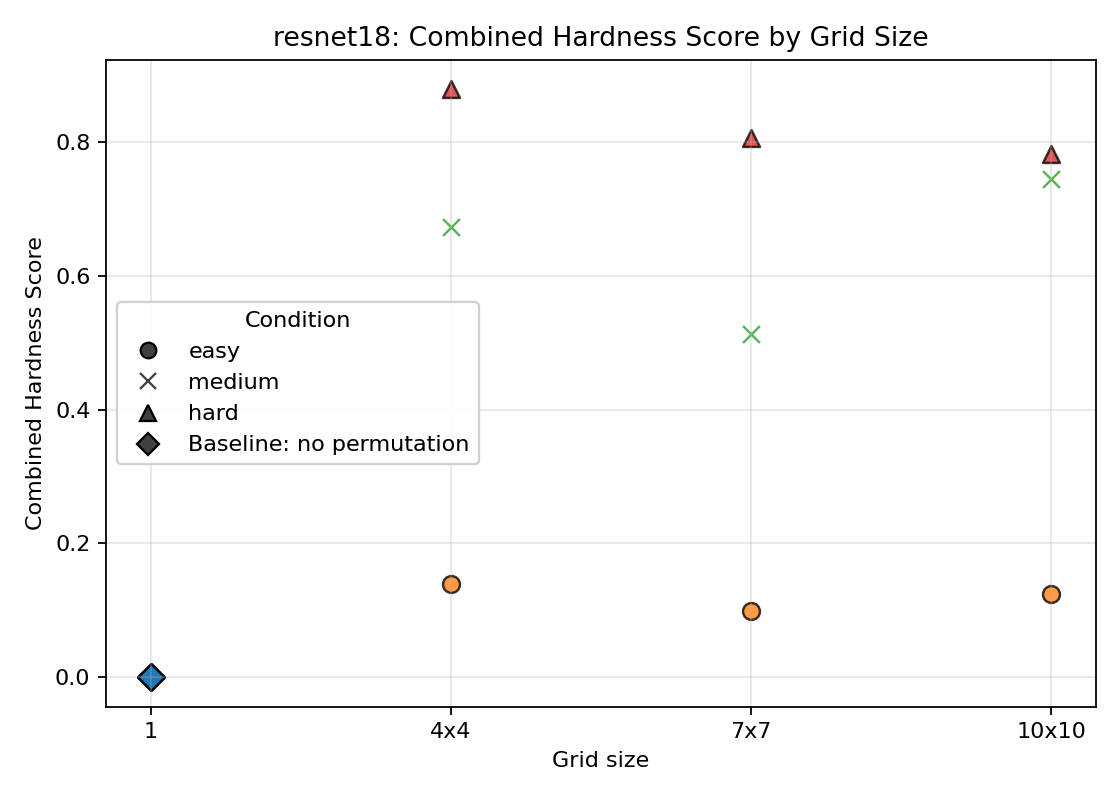

**outputs/figures/part3_global_tile_displacement_grid_vs_hardness.png**

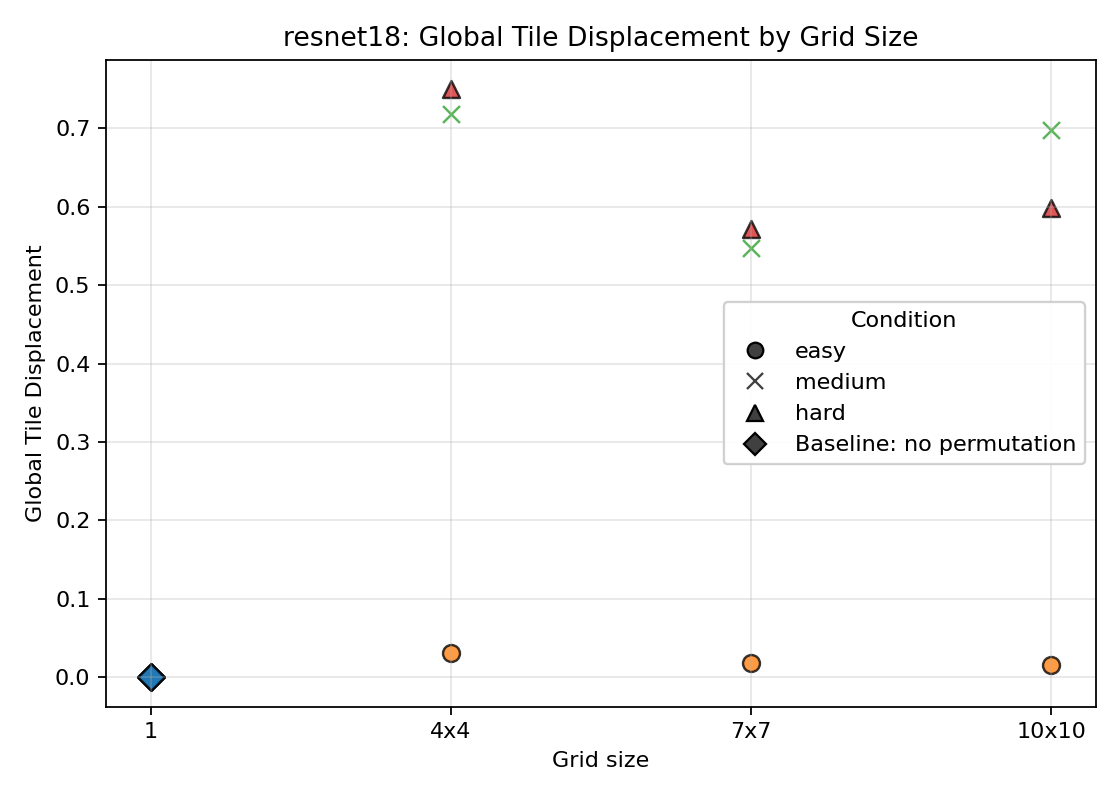

**outputs/figures/part3_spatial_permutation_entropy_grid_vs_hardness.png**

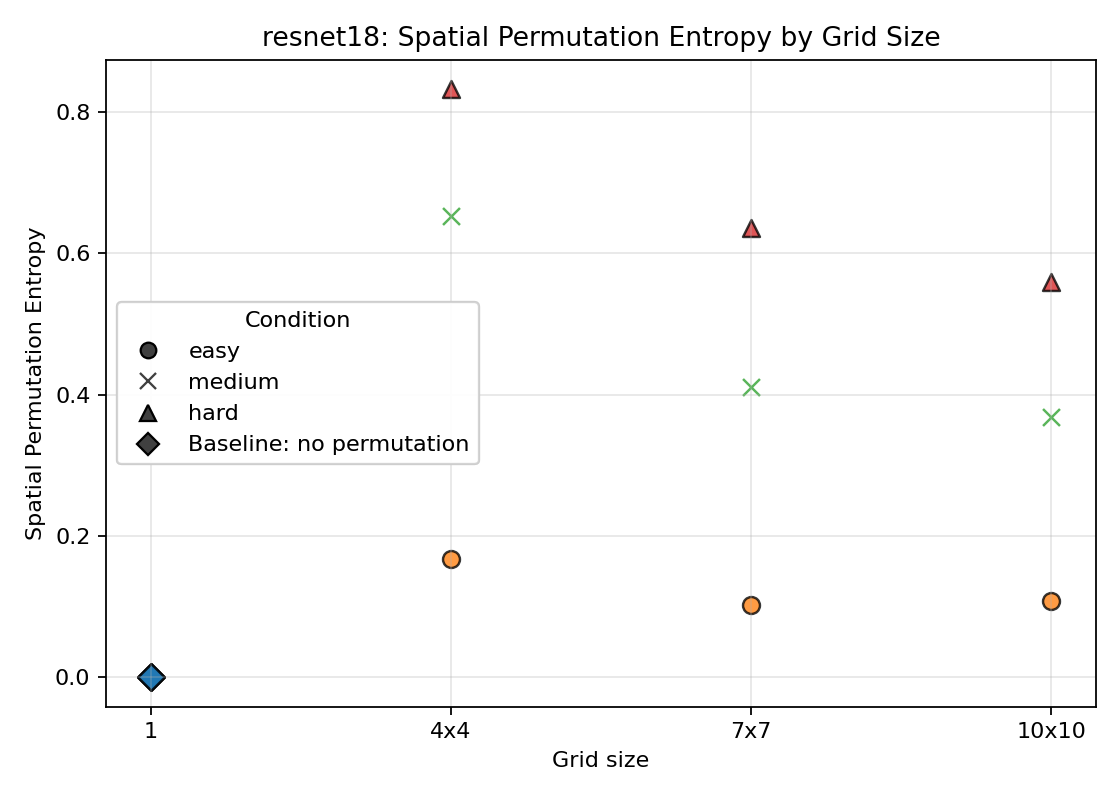

**outputs/figures/part3_adjacency_destruction_hardness_grid_hardness_accuracy_3d.png**

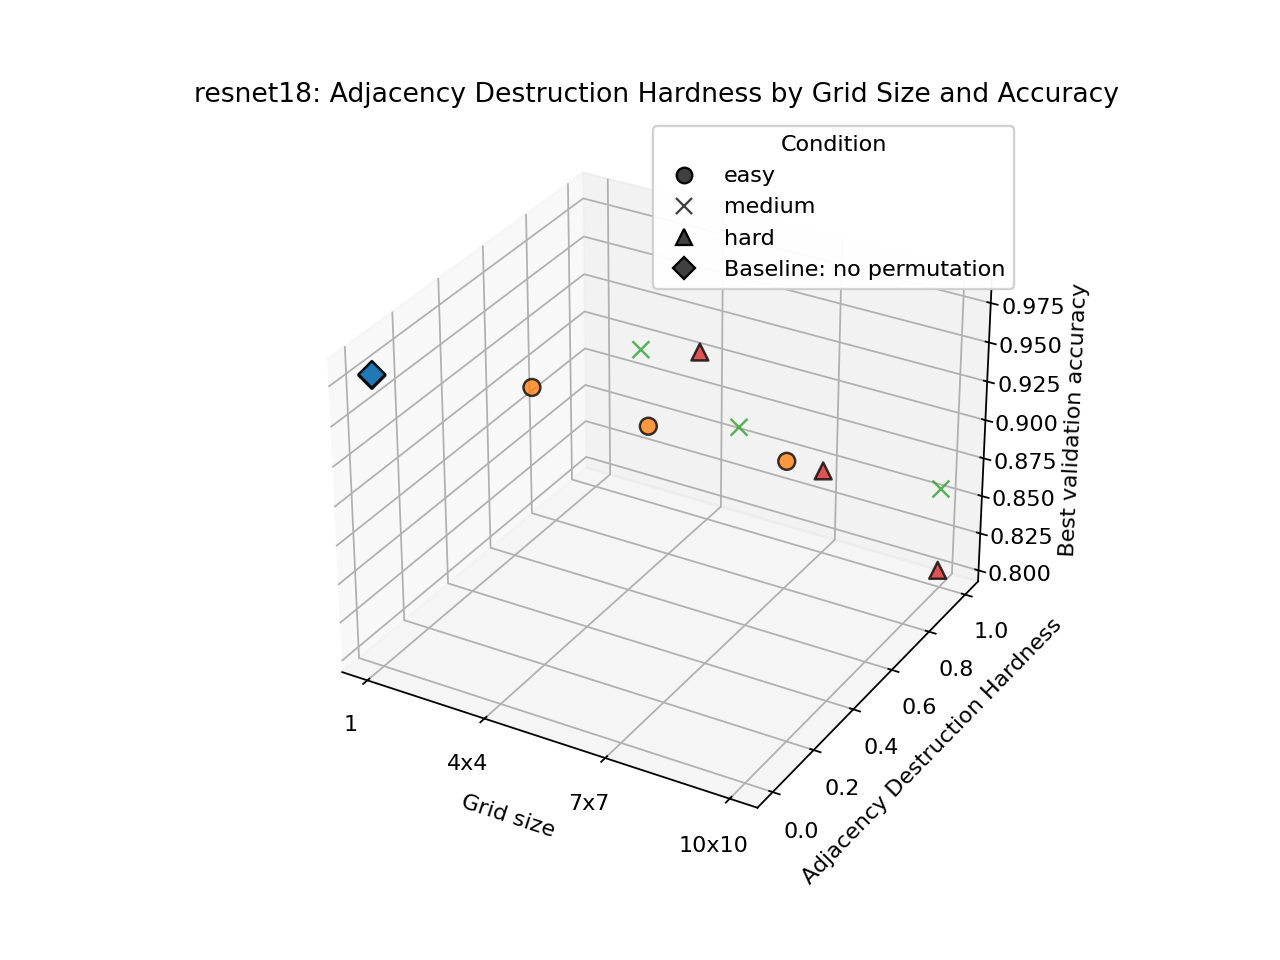

**outputs/figures/part3_combined_hardness_grid_hardness_accuracy_3d.png**

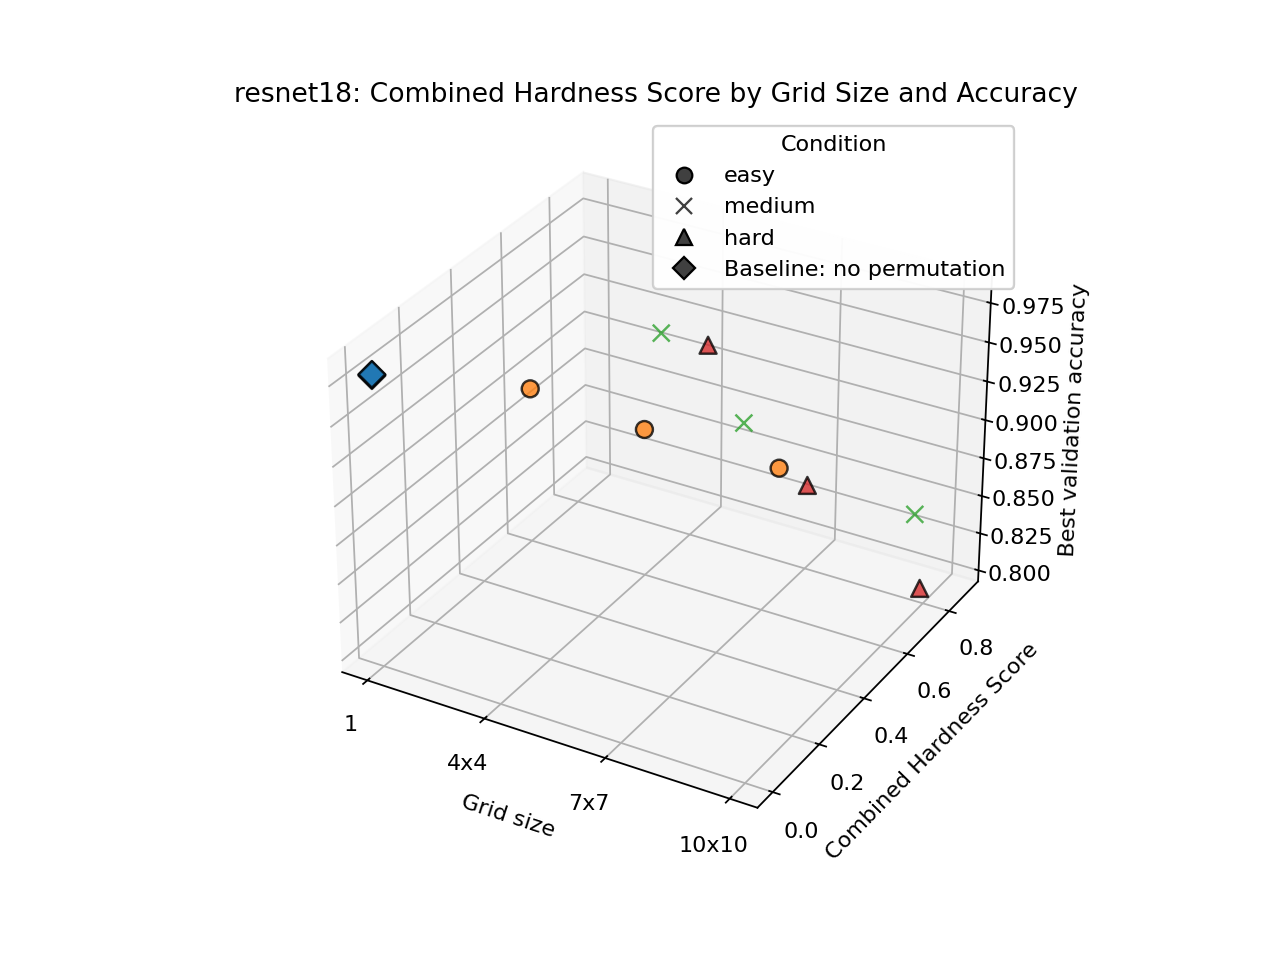

**outputs/figures/part3_global_tile_displacement_grid_hardness_accuracy_3d.png**

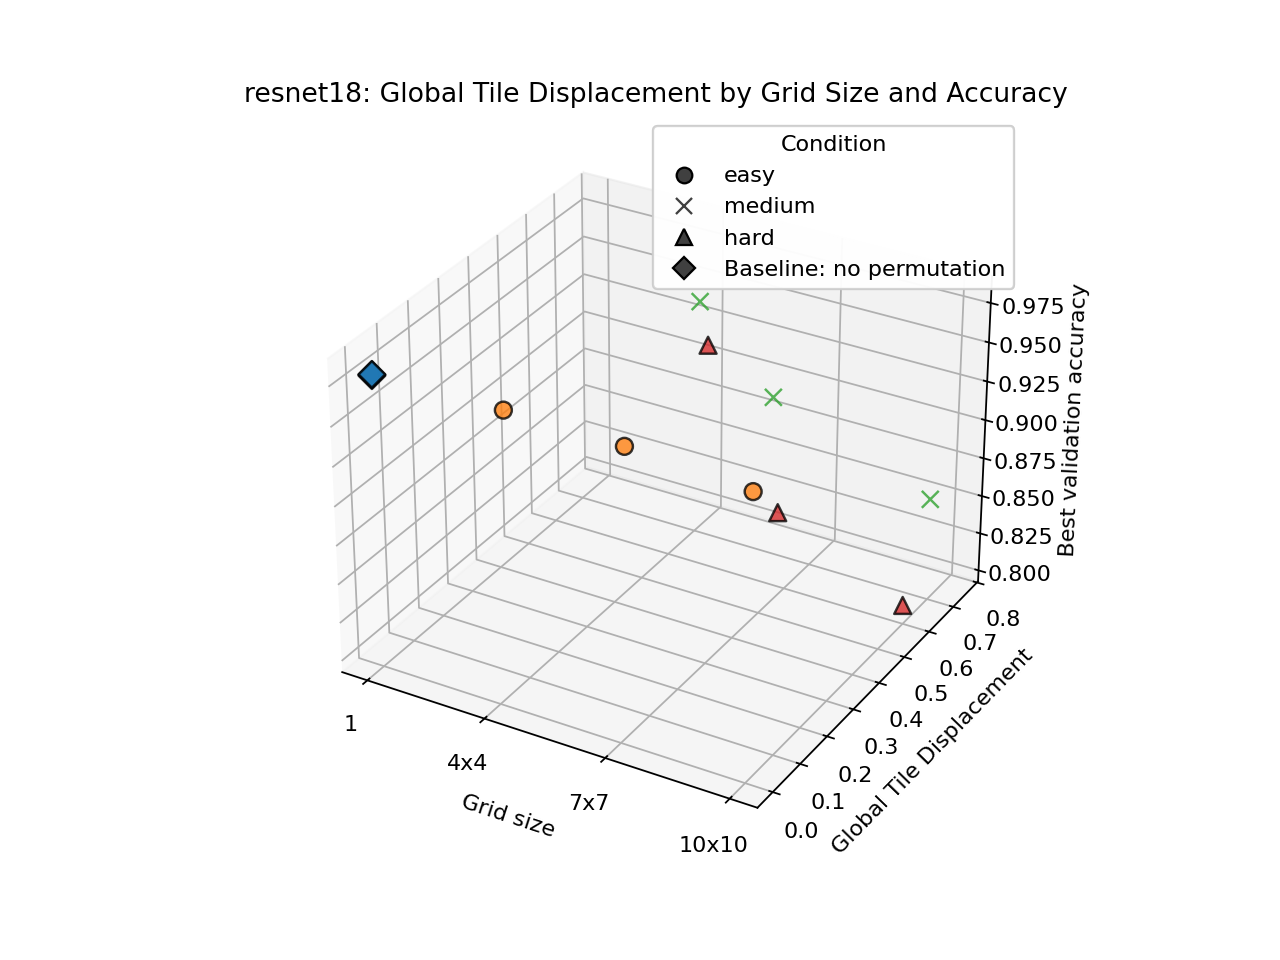

**outputs/figures/part3_spatial_permutation_entropy_grid_hardness_accuracy_3d.png**

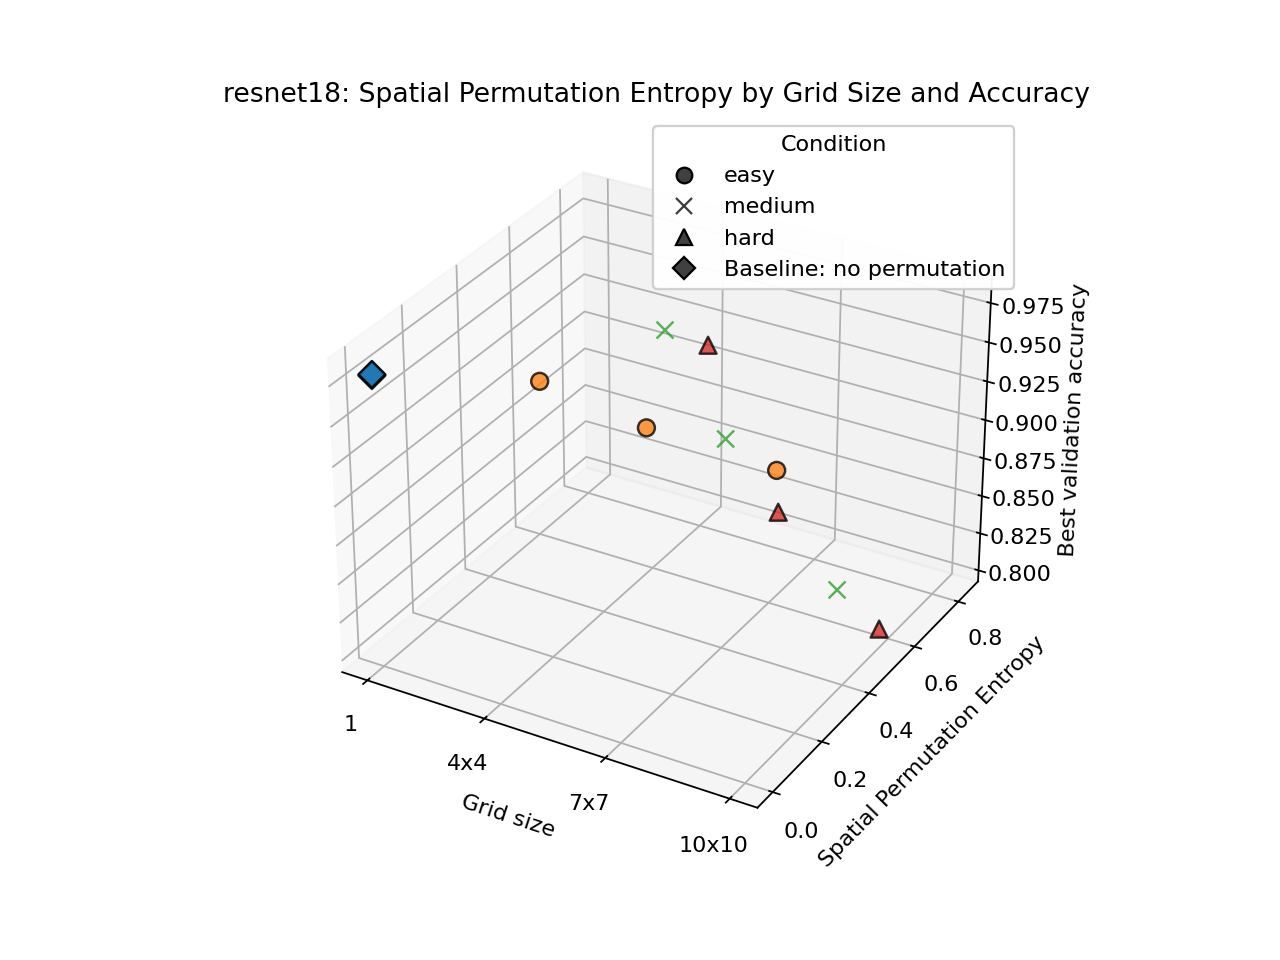

In [23]:
def part3_figure_sort_key(path: Path) -> tuple[int, str]:
    is_3d = path.name.endswith("_3d.png")
    return (1 if is_3d else 0, path.name)


part3_figures = sorted(FIGURES_DIR.glob("part3_*.png"), key=part3_figure_sort_key)
show_images(part3_figures)

In [24]:
# show_tables(
#     [
#         RESULTS_DIR / "tile_permutation_metrics.csv",
#         RESULTS_DIR / "metric_accuracy_joined.csv",
#         RESULTS_DIR / "metric_accuracy_correlations.csv",
#     ]
# )

## Finalize

In [25]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import importlib

import src.utils.notebook_setup as notebook_setup

notebook_setup = importlib.reload(notebook_setup)
notebook_path = PROJECT_ROOT / "src" / "notebooks" / "final_results_overview.ipynb"
export_dir = PROJECT_ROOT / "outputs" / "notebooks"
notebook_setup.export_notebook_to_pdf(notebook_path, export_dir)

Generated PDF: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/final_results_overview.pdf


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/final_results_overview.pdf')